## 1. Load Data And Baseline Audit

Check the raw shape, missing values, duplicate rows, duplicate `order_id`s, and target balance before cleaning.

Load the dataset and display a quick baseline summary.

In [252]:
import pandas as pd

pd.set_option("display.max_columns", None)
df = pd.read_csv("ecommerce_returns.csv")
df.head()

,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
0,ORD010306,CUST04587,43.0,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes
1,ORD012251,CUST02016,33.0,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,NaN,No
2,ORD004778,CUST01696,33.0,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,NaN,No
3,ORD016871,CUST00739,43.0,Female,Electronics,561.73,1,15.10,upi,Next-Day,1.0,0,4.8,0.138,Size/fit issue,Yes
4,ORD018385,CUST03850,40.0,Male,Sports,47.84,5,18.66,Debit Card,Next-Day,2.0,1,5.0,0.070,NaN,No


## 2. Exact Duplicate Rows

Remove rows that are identical across every column.

Count how many fully identical rows exist.

In [253]:
# Exact duplicate rows
df.duplicated().sum()

np.int64(40)

Drop exact duplicates and confirm none remain.

In [254]:
before_rows = len(df)
exact_duplicates = df.duplicated().sum()

df = df.drop_duplicates().copy()

print(f"Exact duplicate rows removed: {exact_duplicates}")
print(f"Rows before: {before_rows}")
print(f"Rows after: {len(df)}")
print(f"Remaining exact duplicates: {df.duplicated().sum()}")

Exact duplicate rows removed: 40
Rows before: 20000
Rows after: 19960
Remaining exact duplicates: 0


## 3. Duplicate `order_id`

`order_id` should identify one transaction. After exact duplicates are removed, any remaining duplicate `order_id`s are conflicting transaction records.

Show the conflicting order_id rows, then keep only the first occurrence.


In [255]:
duplicate_order_rows = df[df["order_id"].duplicated(keep=False)].sort_values("order_id")

print(f"Rows with duplicate order_id: {len(duplicate_order_rows)}")
display(duplicate_order_rows.head(10))

df = df.drop_duplicates(subset="order_id", keep="first").copy()

print(f"Remaining duplicate order_id count: {df['order_id'].duplicated().sum()}")
print(f"Rows after order_id cleaning: {len(df)}")

Rows with duplicate order_id: 40


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
12251,ORD001138,CUST04079,NaN,Female,Sports,50.24,2,32.12,UPI,Express,5.0,1,3.4,0.182,NaN,No
8629,ORD001138,CUST04079,NaN,Female,Sports,50.24,2,32.12,UPI,Express,4.0,1,4.2,0.182,NaN,No
17843,ORD002614,CUST01651,29.0,Female,Fashion,48.01,1,4.66,Debit Card,Express,3.0,0,4.1,0.191,NaN,No
16752,ORD002614,CUST01651,29.0,Female,Fashion,48.01,1,4.66,Debit Card,Express,4.0,0,4.9,0.191,NaN,No
14576,ORD004960,CUST00553,52.0,NaN,Electronics,450.07,1,30.52,Credit Card,Express,5.0,2,4.1,0.062,NaN,No
11706,ORD004960,CUST00553,52.0,NaN,Electronics,450.07,1,30.52,Credit Card,Express,7.0,2,4.9,0.062,NaN,No
9363,ORD006331,CUST00983,59.0,Male,Groceries,50.81,1,35.99,Cash on Delivery,Standard,7.0,2,3.2,0.093,NaN,No
6357,ORD006331,CUST00983,59.0,Male,Groceries,50.81,1,35.99,Cash on Delivery,Standard,8.0,2,2.4,0.093,NaN,No
19170,ORD007551,CUST03360,35.0,Female,Beauty,61.74,1,21.06,Debit Card,Express,3.0,0,4.9,0.376,NaN,No
9346,ORD007551,CUST03360,35.0,Female,Beauty,61.74,1,21.06,Debit Card,Express,4.0,0,4.1,0.376,NaN,No


Remaining duplicate order_id count: 0
Rows after order_id cleaning: 19940


## 4. Standardize `product_category`

First check whether the same product categories appear with different spelling, casing, or extra spaces. Then map them into one clean set of categories.

Show raw category values — many variants for the same real category.

In [256]:
df["product_category"].value_counts(dropna=False)

product_category
Fashion            4522
Electronics        3600
Home & Living      2968
Beauty             2392
Sports             2109
Books              1940
Groceries          1911
FASHION              41
fashion              40
electronics          36
home and living      35
 Fashion             29
ELECTRONICS          27
 Groceries           24
HOME & LIVING        24
 Home & Living       24
GROCERIES            23
grocery              22
BEAUTY               22
sports               22
 Beauty              21
beauty               21
 Electronics         18
 Books               17
 Sports              17
SPORTS               15
BOOKS                13
books                 7
Name: count, dtype: int64

Map every variant to one of the 7 standard category labels.

In [257]:
category_map = {
    "electronics": "Electronics",
    "fashion": "Fashion",
    "home and living": "Home & Living",
    "sports": "Sports",
    "books": "Books",
    "beauty": "Beauty",
    "groceries": "Groceries",
    "grocery": "Groceries",
}

df["product_category"] = (
    df["product_category"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "and", regex=False)
    .map(category_map)
)

Confirm the column now has exactly 7 clean categories.

In [258]:
df["product_category"].value_counts(dropna=False)

product_category
Fashion          4632
Electronics      3681
Home & Living    3051
Beauty           2456
Sports           2163
Groceries        1980
Books            1977
Name: count, dtype: int64

## 5. Standardize `customer_gender`

First check whether gender values are split across inconsistent labels such as `F`, `M`, lowercase text, extra spaces, or missing values. Then standardize them.

Show raw gender values — inconsistent casing, abbreviations, blanks.

In [259]:
df["customer_gender"].value_counts(dropna=False)

customer_gender
Female      9646
Male        8455
Other        950
NaN          598
 Female       55
M             48
female        48
F             44
 Male         44
male          43
 Other         4
Unknown        3
other          2
Name: count, dtype: int64

Standardize to Female / Male / Other / Unknown.

In [260]:
gender_map = {
    "female": "Female",
    "f": "Female",
    "male": "Male",
    "m": "Male",
    "other": "Other",
    "unknown": "Unknown",
}

df["customer_gender"] = (
    df["customer_gender"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .map(gender_map)
    .fillna("Unknown")
)

Confirm the column has only the 4 expected gender labels.

In [261]:
df["customer_gender"].value_counts(dropna=False)

customer_gender
Female     9793
Male       8590
Other       956
Unknown     601
Name: count, dtype: int64

## 6. Standardize `payment_method`

First check whether the same payment method appears under multiple labels. Then map each alias to one canonical payment method.

Show raw payment values — aliases like COD, upi, creditcard.

In [262]:
df["payment_method"].value_counts(dropna=False)

payment_method
Credit Card           6074
Debit Card            4516
Wallet                3484
Cash on Delivery      3227
UPI                   2044
NaN                    199
credit card             44
wallet                  43
 CREDIT CARD            39
CreditCard              38
debit card              36
 DEBIT CARD             35
cash_on_delivery        30
DebitCard               29
 WALLET                 26
upi                     23
 Cash on Delivery       21
 UPI                    18
COD                     14
Name: count, dtype: int64

Map every alias to one of the 5 canonical payment labels.

In [263]:
payment_map = {
    "credit card": "Credit Card",
    "creditcard": "Credit Card",
    "debit card": "Debit Card",
    "debitcard": "Debit Card",
    "wallet": "Wallet",
    "cash on delivery": "Cash on Delivery",
    "cod": "Cash on Delivery",
    "upi": "UPI",
}

df["payment_method"] = (
    df["payment_method"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("_", " ", regex=False)
    .map(payment_map)
    .fillna("Unknown")
)

Confirm the column is clean.

In [264]:
df["payment_method"].value_counts(dropna=False)

payment_method
Credit Card         6195
Debit Card          4616
Wallet              3553
Cash on Delivery    3292
UPI                 2085
Unknown              199
Name: count, dtype: int64

## 7. Fix `return_reason` And `returned` Consistency

`return_reason` should agree with `returned`.

- If `returned = No`, set `return_reason` to `"Not Returned"`.
- If `returned = Yes` and `return_reason` is missing, set it to `"Not Specified"`.

Count rows where return_reason conflicts with the returned flag.

In [265]:
problem_counts = pd.Series({
    "No but has return_reason": ((df["returned"] == "No") & df["return_reason"].notna()).sum(),
    "Yes but missing return_reason": ((df["returned"] == "Yes") & df["return_reason"].isna()).sum()
})

problem_counts

No but has return_reason         192
Yes but missing return_reason     98
dtype: int64

Apply the two consistency rules.

In [266]:
df.loc[df["returned"] == "No", "return_reason"] = "Not Returned"

df.loc[
    (df["returned"] == "Yes") & (df["return_reason"].isna()),
    "return_reason"
] = "Not Specified"

Validate — both conflict counts must be 0.

In [267]:
validation_counts = pd.Series({
    "No but has real return_reason": ((df["returned"] == "No") & (df["return_reason"] != "Not Returned")).sum(),
    "Yes but missing return_reason": ((df["returned"] == "Yes") & df["return_reason"].isna()).sum()
})

validation_counts

No but has real return_reason    0
Yes but missing return_reason    0
dtype: int64

## 8. Age fix

Distribution and boxplot before fixing invalid ages.

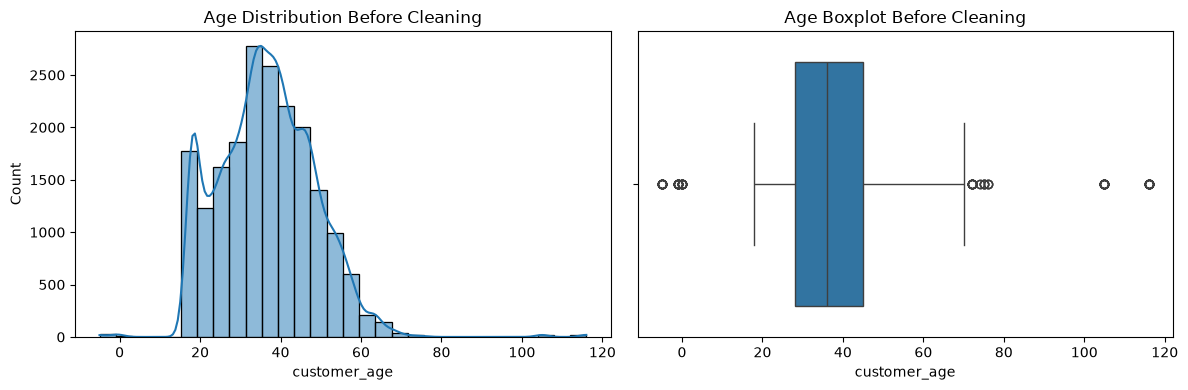

In [268]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_age"], bins=30, kde=True)
plt.title("Age Distribution Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_age"])
plt.title("Age Boxplot Before Cleaning")

plt.tight_layout()
plt.show()

Replace out-of-range age values (< 18 or > 80) with NaN.

In [269]:
df.loc[
    (df["customer_age"] < 18) | (df["customer_age"] > 80),
    "customer_age"
] = pd.NA

age_median = df["customer_age"].median()

df["customer_age"] = df["customer_age"].fillna(age_median)
df["customer_age"] = df["customer_age"].round().astype(int)

Validate — no missing, none below 18 or above 80.

In [270]:
pd.Series({
    "missing_customer_age": df["customer_age"].isna().sum(),
    "below_18": (df["customer_age"] < 18).sum(),
    "above_80": (df["customer_age"] > 80).sum()
})

missing_customer_age    0
below_18                0
above_80                0
dtype: int64

Distribution and boxplot after cleaning.

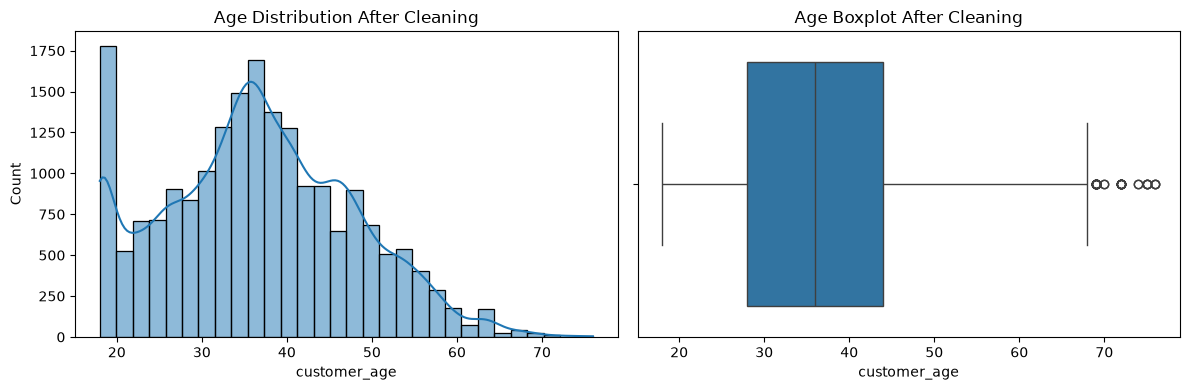

In [271]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_age"], bins=30, kde=True)
plt.title("Age Distribution After Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_age"])
plt.title("Age Boxplot After Cleaning")

plt.tight_layout()
plt.show()

## 9. Fix invalid customer_rating

Identify rows with ratings outside the valid 1–5 scale.

In [272]:
invalid_rating = df[
    df["customer_rating"].isna() |
    (df["customer_rating"] < 1) |
    (df["customer_rating"] > 5)
]

print("Invalid or missing customer_rating rows:", len(invalid_rating))
invalid_rating[["product_category", "customer_rating"]].head()

Invalid or missing customer_rating rows: 677


,product_category,customer_rating
58,Beauty,NaN
71,Fashion,NaN
116,Sports,NaN
154,Groceries,NaN
181,Books,NaN


Distribution and boxplot before fixing.

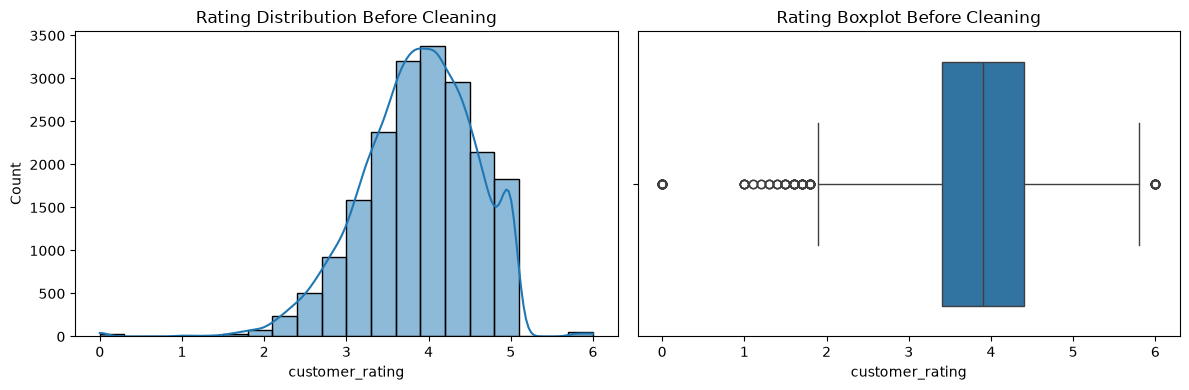

In [273]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_rating"], bins=20, kde=True)
plt.title("Rating Distribution Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_rating"])
plt.title("Rating Boxplot Before Cleaning")

plt.tight_layout()
plt.show()

Convert invalid ratings to NaN, then fill with category-wise median.

In [274]:
df.loc[
    (df["customer_rating"] < 1) | (df["customer_rating"] > 5),
    "customer_rating"
] = pd.NA

category_rating_median = df.groupby("product_category")["customer_rating"].transform("median")

df["customer_rating"] = (
    df["customer_rating"]
    .fillna(category_rating_median)
    .fillna(df["customer_rating"].median())
)

Validate — no missing, none outside 1–5.

In [275]:
rating_validation = pd.Series({
    "missing_customer_rating": df["customer_rating"].isna().sum(),
    "below_1": (df["customer_rating"] < 1).sum(),
    "above_5": (df["customer_rating"] > 5).sum()
})

rating_validation

missing_customer_rating    0
below_1                    0
above_5                    0
dtype: int64

Distribution and boxplot after cleaning.

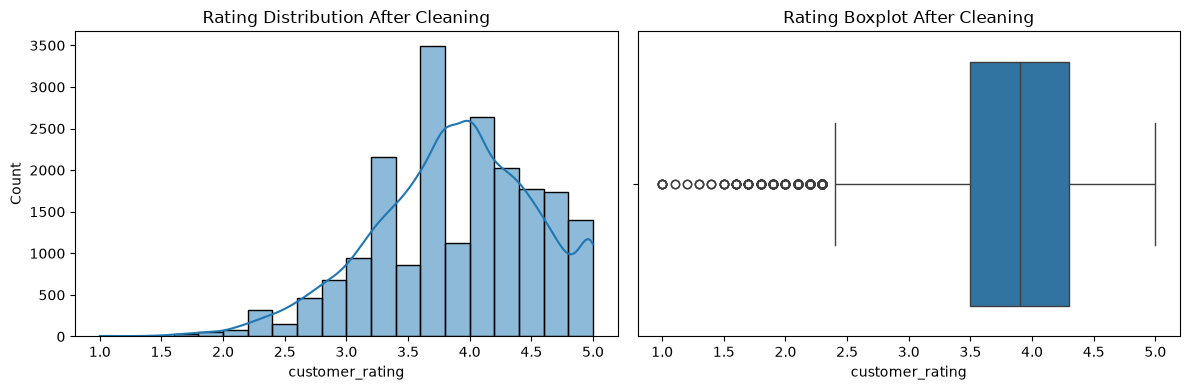

In [276]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_rating"], bins=20, kde=True)
plt.title("Rating Distribution After Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_rating"])
plt.title("Rating Boxplot After Cleaning")

plt.tight_layout()
plt.show()

## 10. Fix invalid discount_percent

Identify rows with discount values below 0 or above 100.

In [277]:
invalid_discount = df[
    (df["discount_percent"] < 0) |
    (df["discount_percent"] > 100)
]

print("Invalid discount_percent rows:", len(invalid_discount))
invalid_discount[["discount_percent"]].head()

Invalid discount_percent rows: 80


,discount_percent
311,-10.0
482,-3.0
514,-3.0
574,105.0
1211,-3.0


Distribution and boxplot before clipping.

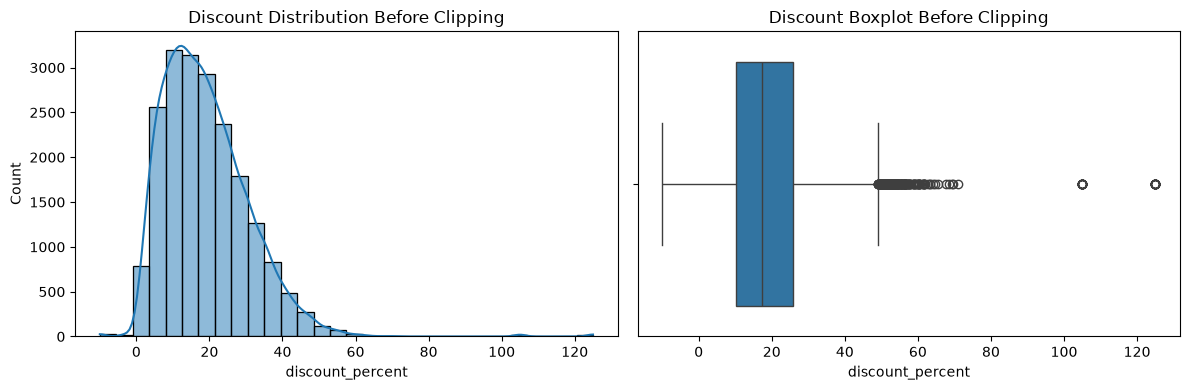

In [278]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["discount_percent"], bins=30, kde=True)
plt.title("Discount Distribution Before Clipping")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["discount_percent"])
plt.title("Discount Boxplot Before Clipping")

plt.tight_layout()
plt.show()

Clip negative discounts to 0 and values above 100 to 100.

In [279]:
df["discount_percent"] = df["discount_percent"].clip(lower=0, upper=100)

Validate — no values below 0 or above 100.

In [280]:
discount_validation = pd.Series({
    "below_0": (df["discount_percent"] < 0).sum(),
    "above_100": (df["discount_percent"] > 100).sum()
})

discount_validation

below_0      0
above_100    0
dtype: int64

Distribution and boxplot after clipping.

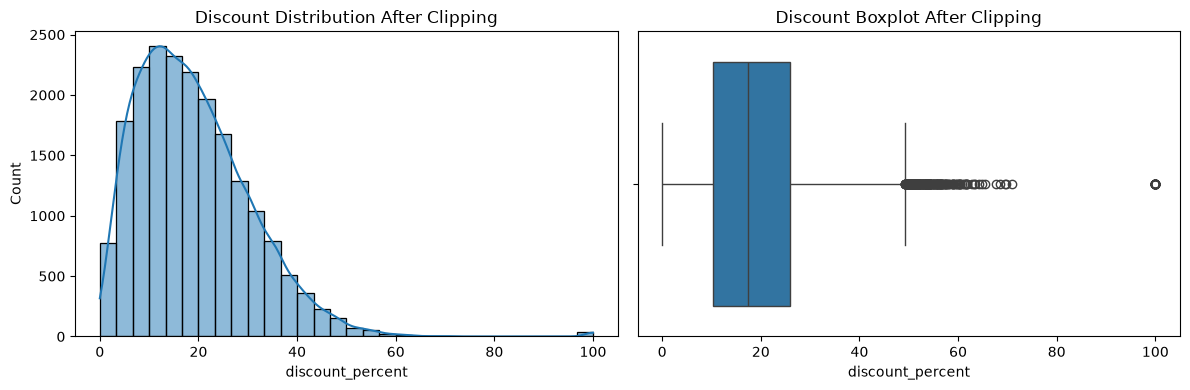

In [281]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["discount_percent"], bins=30, kde=True)
plt.title("Discount Distribution After Clipping")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["discount_percent"])
plt.title("Discount Boxplot After Clipping")

plt.tight_layout()
plt.show()

## 11. Fix delivery time and delay issues

Count missing delivery_time_days and extreme delay values.

In [282]:
delivery_issue_counts = pd.Series({
    "missing_delivery_time": df["delivery_time_days"].isna().sum(),
    "delivery_time_less_than_1": (df["delivery_time_days"] < 1).sum(),
    "early_delivery_delay_minus_1": (df["delivery_delay_days"] == -1).sum(),
    "extreme_delay_above_10": (df["delivery_delay_days"] > 10).sum()
})

delivery_issue_counts

missing_delivery_time            299
delivery_time_less_than_1         60
early_delivery_delay_minus_1    1578
extreme_delay_above_10           117
dtype: int64

Boxplots of both delivery columns before cleaning.

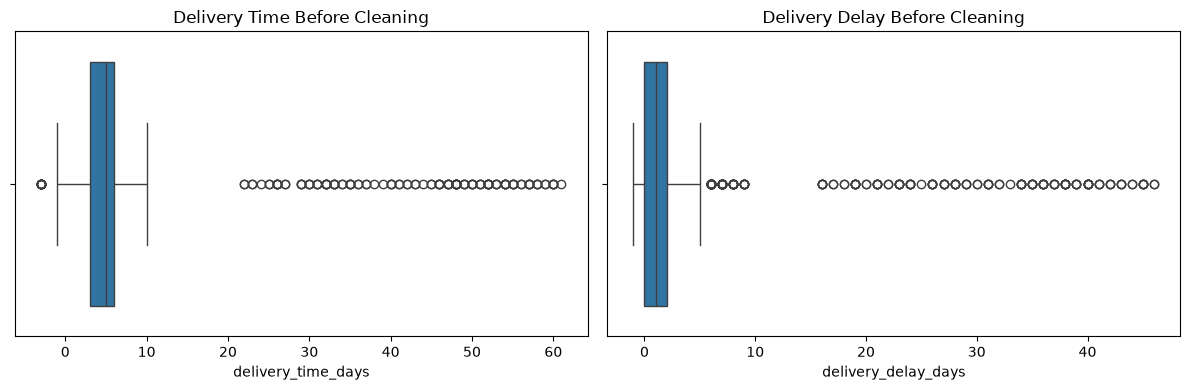

In [283]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["delivery_time_days"])
plt.title("Delivery Time Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["delivery_delay_days"])
plt.title("Delivery Delay Before Cleaning")

plt.tight_layout()
plt.show()

Convert delivery_time_days < 1 to NaN.

In [284]:
df.loc[df["delivery_time_days"] < 1, "delivery_time_days"] = pd.NA

Reconstruct missing delivery_time_days from shipping method + delay.

In [285]:
expected_days = {
    "Standard": 5,
    "Express": 3,
    "Next-Day": 1
}

reconstructed_delivery_time = (
    df["shipping_method"].map(expected_days) + df["delivery_delay_days"]
).clip(lower=1)

df["delivery_time_days"] = df["delivery_time_days"].fillna(reconstructed_delivery_time)

Flag orders where delivery delay exceeds 10 days.

In [286]:
df["is_extreme_delivery_delay"] = df["delivery_delay_days"] > 10

Validate — no missing delivery_time_days, check flag count.

In [287]:
delivery_validation = pd.Series({
    "missing_delivery_time": df["delivery_time_days"].isna().sum(),
    "delivery_time_less_than_1": (df["delivery_time_days"] < 1).sum(),
    "early_delivery_delay_minus_1": (df["delivery_delay_days"] == -1).sum(),
    "extreme_delay_flagged": df["is_extreme_delivery_delay"].sum()
})

delivery_validation

missing_delivery_time              0
delivery_time_less_than_1          0
early_delivery_delay_minus_1    1578
extreme_delay_flagged            117
dtype: int64

Boxplots after cleaning.

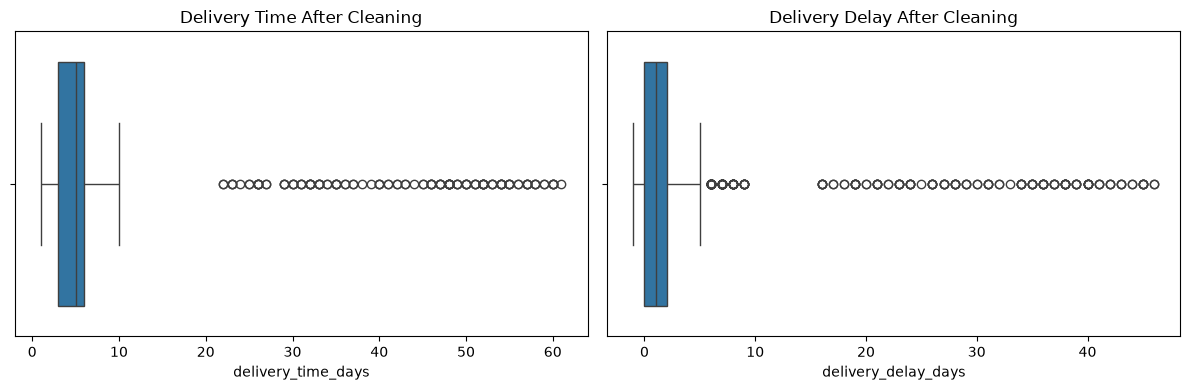

In [288]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["delivery_time_days"])
plt.title("Delivery Time After Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["delivery_delay_days"])
plt.title("Delivery Delay After Cleaning")

plt.tight_layout()
plt.show()

## 12.  Impute missing customer fields

Check which customer-level fields still have missing values.

In [289]:
customer_fields = ["customer_age", "customer_gender", "past_return_rate"]

df[customer_fields].isna().sum()

customer_age          0
customer_gender       0
past_return_rate    199
dtype: int64

Fill missing customer_age from same customer_id, then global median.

In [290]:
customer_age_median = df.groupby("customer_id")["customer_age"].transform("median")

df["customer_age"] = (
    df["customer_age"]
    .fillna(customer_age_median)
    .fillna(df["customer_age"].median())
    .round()
    .astype(int)
)

Fill missing customer_gender from same customer_id, then Unknown.

In [291]:
customer_gender_mode = (
    df.dropna(subset=["customer_gender"])
    .groupby("customer_id")["customer_gender"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
)

df["customer_gender"] = (
    df["customer_gender"]
    .fillna(df["customer_id"].map(customer_gender_mode))
    .fillna("Unknown")
)

Fill missing past_return_rate from same customer_id, then global median.

In [292]:
customer_return_rate_median = df.groupby("customer_id")["past_return_rate"].transform("median")

df["past_return_rate"] = (
    df["past_return_rate"]
    .fillna(customer_return_rate_median)
    .fillna(df["past_return_rate"].median())
)

Second pass to catch any remaining past_return_rate gaps.

In [293]:
customer_return_rate_median = df.groupby("customer_id")["past_return_rate"].transform("median")

df["past_return_rate"] = (
    df["past_return_rate"]
    .fillna(customer_return_rate_median)
    .fillna(df["past_return_rate"].median())
)

## 13.  Impute missing transaction fields

Check which transaction-level fields still have missing values.

In [294]:
transaction_fields = [
    "payment_method",
    "delivery_time_days",
    "customer_rating",
    "discount_percent"
]

df[transaction_fields].isna().sum()

payment_method        0
delivery_time_days    0
customer_rating       0
discount_percent      0
dtype: int64

Fill missing payment_method with the most common value.

In [295]:
payment_mode = df["payment_method"].mode()[0]
df["payment_method"] = df["payment_method"].fillna(payment_mode)

Reconstruct missing delivery_time_days from shipping method + delay.

In [296]:
expected_days = {
    "Standard": 5,
    "Express": 3,
    "Next-Day": 1
}

reconstructed_delivery_time = (
    df["shipping_method"].map(expected_days) + df["delivery_delay_days"]
).clip(lower=1)

df["delivery_time_days"] = df["delivery_time_days"].fillna(reconstructed_delivery_time)
df["delivery_time_days"] = df["delivery_time_days"].round().astype(int)

Fill missing customer_rating with product-category median.

In [297]:
category_rating_median = df.groupby("product_category")["customer_rating"].transform("median")

df["customer_rating"] = (
    df["customer_rating"]
    .fillna(category_rating_median)
    .fillna(df["customer_rating"].median())
)

Fill missing discount_percent with product-category median.

In [298]:
category_discount_median = df.groupby("product_category")["discount_percent"].transform("median")

df["discount_percent"] = (
    df["discount_percent"]
    .fillna(category_discount_median)
    .fillna(df["discount_percent"].median())
)

Validate — all four transaction fields should be fully populated.

In [299]:
df[transaction_fields].isna().sum()

payment_method        0
delivery_time_days    0
customer_rating       0
discount_percent      0
dtype: int64

## 14. Handle/flag outliers

IQR-based outlier count for each numeric column — informational only.

In [300]:
numeric_cols = [
    "customer_age",
    "product_price",
    "order_quantity",
    "discount_percent",
    "delivery_time_days",
    "delivery_delay_days",
    "customer_rating",
    "past_return_rate"
]

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,column,lower_bound,upper_bound,outlier_count
0,customer_age,4.00000,68.00000,45
1,product_price,-137.64125,348.78875,1680
2,order_quantity,-2.00000,6.00000,100
3,discount_percent,-13.01000,49.15000,238
4,delivery_time_days,-1.50000,10.50000,117
5,delivery_delay_days,-3.00000,5.00000,202
6,customer_rating,2.30000,5.50000,367
7,past_return_rate,-0.20650,0.51750,410


Create boolean flags for business-meaningful outliers.

In [301]:
df["is_high_value_product"] = df["product_price"] > df["product_price"].quantile(0.99)
df["is_bulk_order"] = df["order_quantity"] > 10
df["is_extreme_delivery_delay"] = df["delivery_delay_days"] > 10

df[["is_high_value_product", "is_bulk_order", "is_extreme_delivery_delay"]].sum()

is_high_value_product        200
is_bulk_order                100
is_extreme_delivery_delay    117
dtype: int64